In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
%matplotlib inline

In [3]:
# Path to the downloaded file
file_path = 'amz_uk_price_prediction_dataset.csv'

# Read the dataset
df = pd.read_csv(file_path)
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
# Create crosstab
crosstab = pd.crosstab(df['category'], df['isBestSeller'])

# Calculate proportion of best-sellers per category
crosstab['Proportion_BestSeller'] = crosstab[True] / (crosstab[True] + crosstab[False])

# Sort categories by proportion in descending order
crosstab_sorted = crosstab.sort_values('Proportion_BestSeller', ascending=False)

# Display top categories with highest proportion
print(crosstab_sorted.head(10))

isBestSeller                    False  True  Proportion_BestSeller
category                                                          
Grocery                          9008   556               0.058135
Smart Home Security & Lighting     98     6               0.057692
Health & Personal Care           9017   552               0.057686
Mobile Phone Accessories          248    11               0.042471
Power & Hand Tools               8353   306               0.035339
Billiard, Snooker & Pool          241     8               0.032129
Pet Supplies                     9152   285               0.030200
Home Brewing & Wine Making        239     7               0.028455
Wind Instruments                  243     7               0.028000
Mirrors                           243     7               0.028000


In [25]:
print(crosstab.columns)

Index([False, True, 'Proportion_BestSeller'], dtype='object', name='isBestSeller')


In [31]:
from scipy.stats import chi2_contingency
import numpy as np

# Select columns by integer position (0 for 'False', 1 for 'True')
chi2, p, dof, expected = chi2_contingency(crosstab.iloc[:, [0, 1]])

# Calculate Cramér's V
n = crosstab.iloc[:, [0, 1]].sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.iloc[:, [0, 1]].shape) - 1)))

print(f"Chi-square test: chi2={chi2:.2f}, p-value={p:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square test: chi2=36540.20, p-value=0.0000
Cramér's V: 0.1223


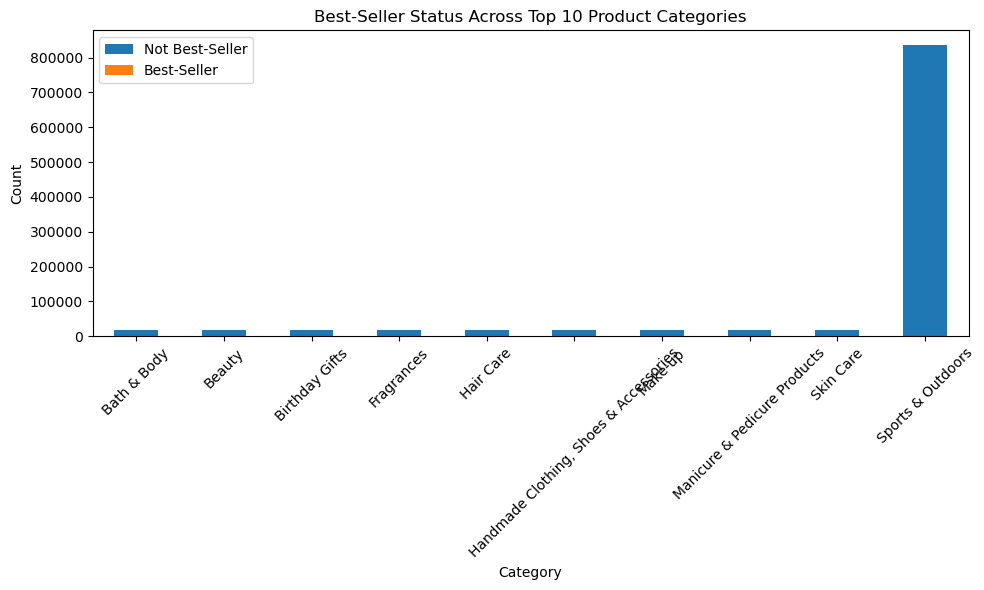

In [9]:
# For better visualization, filter top 10 categories by count
top_categories = df['category'].value_counts().head(10).index
crosstab_top = pd.crosstab(df[df['category'].isin(top_categories)]['category'], df['isBestSeller'])

# Plot stacked bar chart
crosstab_top.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Best-Seller Status Across Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(['Not Best-Seller', 'Best-Seller'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"Original dataset size: {len(df)}")
print(f"Dataset size after removing outliers: {len(df_no_outliers)}")

Original dataset size: 2443651
Dataset size after removing outliers: 2115963


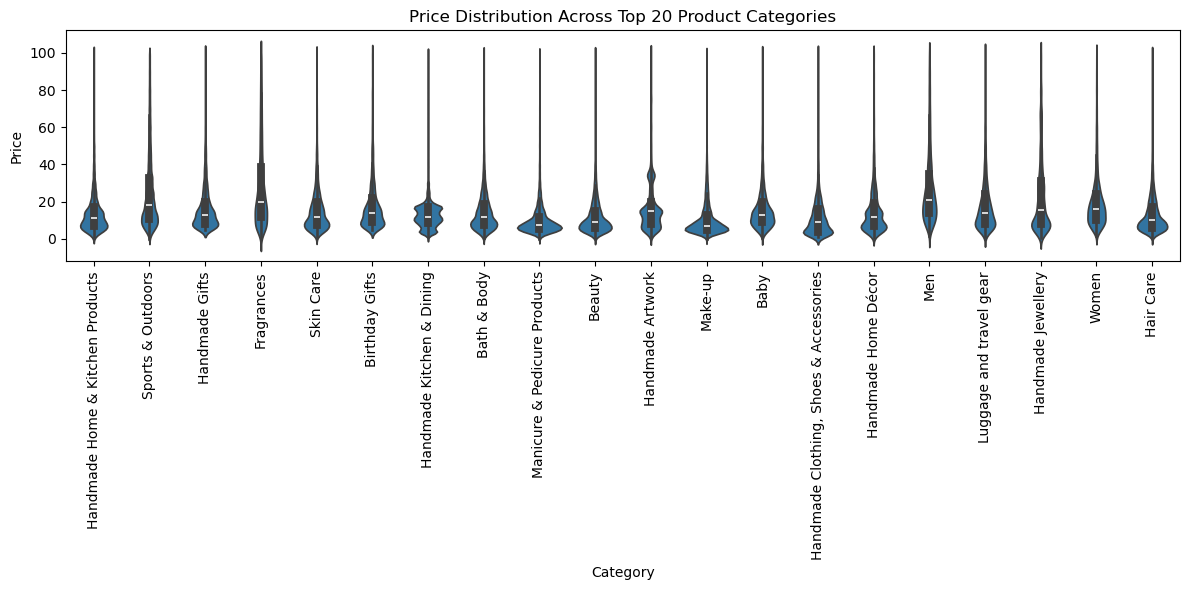

Category with highest median price:
category
Desktop PCs    74.0
Name: price, dtype: float64


In [13]:
# Filter top 20 categories by count
top_20_categories = df_no_outliers['category'].value_counts().head(20).index
df_top_20 = df_no_outliers[df_no_outliers['category'].isin(top_20_categories)]

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='category', y='price', data=df_top_20)
plt.title('Price Distribution Across Top 20 Product Categories')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Calculate median price per category (no filtering)
median_prices = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
print("Category with highest median price:")
print(median_prices.head(1))

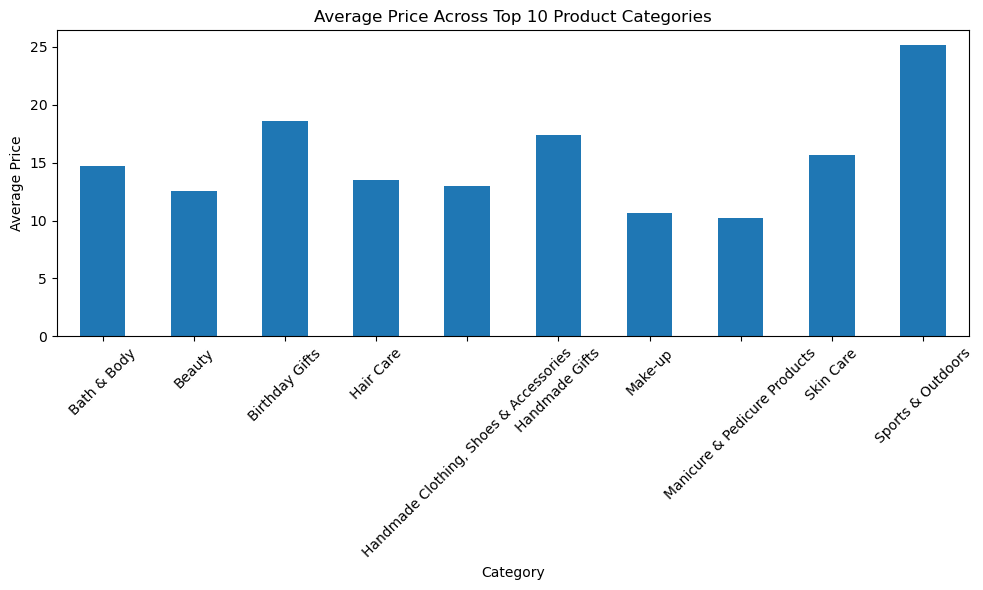

Category with highest average price:
category
Motherboards    68.772432
Name: price, dtype: float64


In [15]:
# Filter top 10 categories by count
top_10_categories = df_no_outliers['category'].value_counts().head(10).index
avg_prices_top_10 = df_no_outliers[df_no_outliers['category'].isin(top_10_categories)].groupby('category')['price'].mean()

# Bar chart
plt.figure(figsize=(10, 6))
avg_prices_top_10.plot(kind='bar')
plt.title('Average Price Across Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate average price per category (no filtering)
avg_prices = df_no_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
print("Category with highest average price:")
print(avg_prices.head(1))

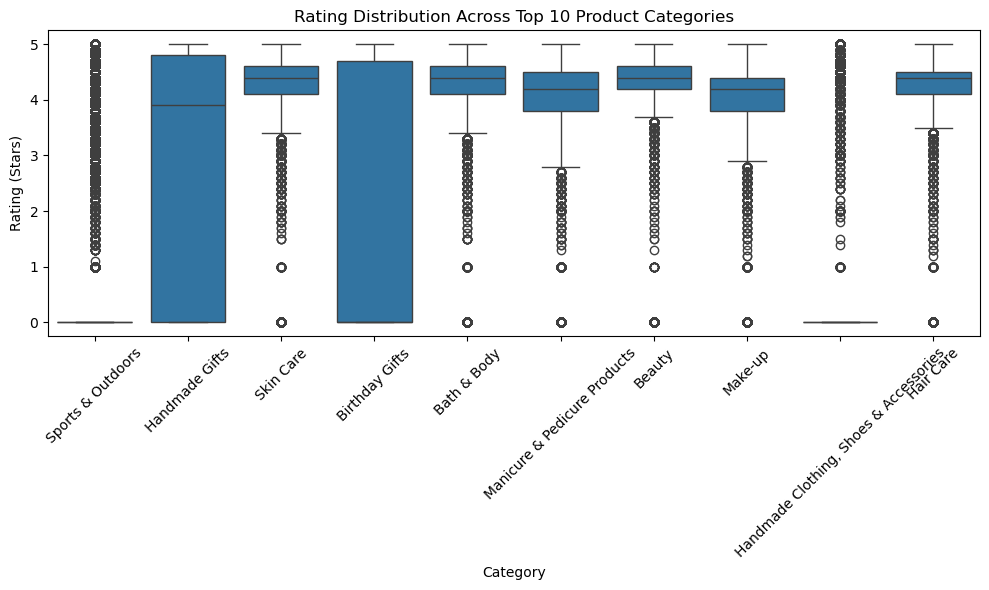

Category with highest median rating:
category
Computer Memory    4.7
Name: stars, dtype: float64


In [23]:
# Box plot for top 10 categories
df_top_10 = df_no_outliers[df_no_outliers['category'].isin(top_10_categories)]
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='stars', data=df_top_10)
plt.title('Rating Distribution Across Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Rating (Stars)')  # Fixed the string
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate median rating per category (no filtering)
median_ratings = df_no_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
print("Category with highest median rating:")
print(median_ratings.head(1))

In [19]:
# Calculate Pearson correlation
correlation = df_no_outliers[['price', 'stars']].corr().iloc[0, 1]
print(f"Correlation coefficient between price and stars: {correlation:.4f}")

# For significance, we can use scipy.stats
from scipy.stats import pearsonr
corr, p_value = pearsonr(df_no_outliers['price'], df_no_outliers['stars'])
print(f"P-value for correlation: {p_value:.4f}")

Correlation coefficient between price and stars: -0.0777
P-value for correlation: 0.0000


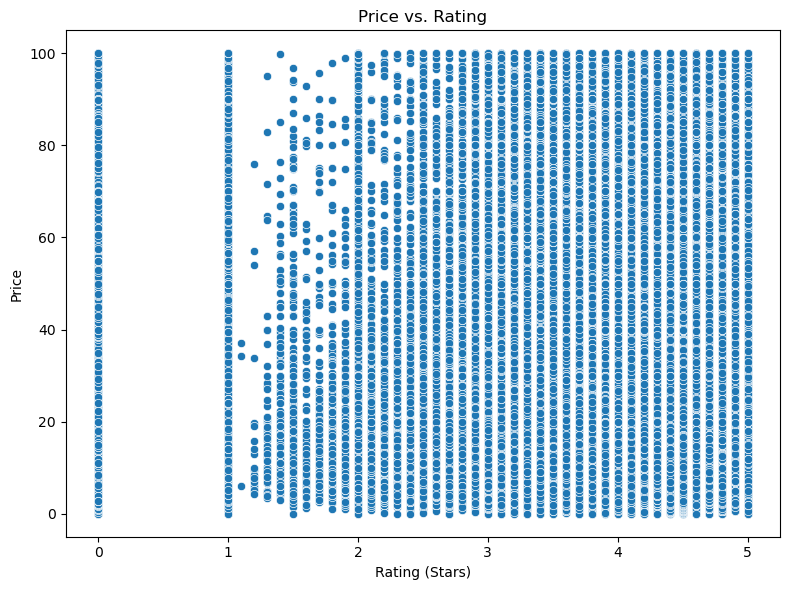

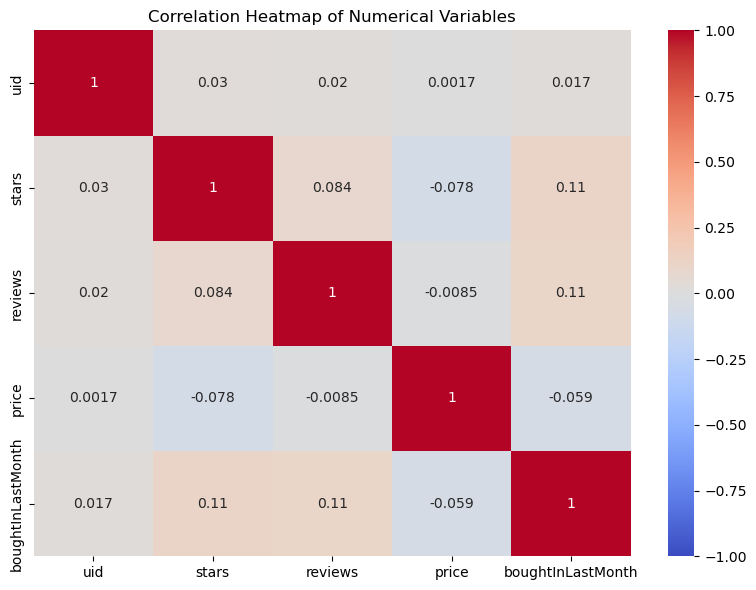

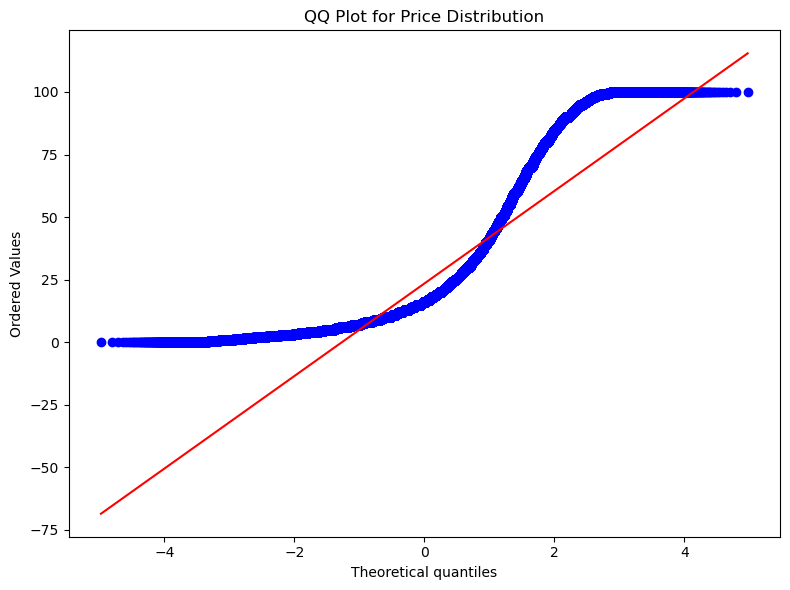

In [21]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='stars', y='price', data=df_no_outliers)
plt.title('Price vs. Rating')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_no_outliers.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

# QQ plot for price distribution
from scipy.stats import probplot
plt.figure(figsize=(8, 6))
probplot(df_no_outliers['price'], dist="norm", plot=plt)
plt.title('QQ Plot for Price Distribution')
plt.tight_layout()
plt.show()